# Mammalian methylation clocks: what the residuals actually say

This notebook rebuilds the whole analysis from the real Mammalian Methylation
Consortium release. Nothing here is simulated.

**The question.** DNA methylation clocks predict chronological age from
chemical marks on the genome, and they work across mammals. If a clock tells us
how fast an animal is ageing biologically, then comparing that rate to what body
size predicts should reveal which species have unusual ageing. Naked mole rats
and bowhead whales are the textbook candidates.

**The answer, in short.** The clocks are excellent. The cross-species rate
comparison mostly is not, because the standard rate measure is mechanically tied
to how wide an age range each species was sampled over. Once that is controlled,
body size explains essentially nothing, and only one species out of 126 remains
a statistically defensible outlier.

Run the pipeline first if the processed files are not present:

```
python src/01_ingest.py
python src/02_clock_validation.py
python src/03_aging_rate_model.py
python src/04_interpretability.py
```

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC, RES = ROOT/"data"/"processed", ROOT/"results"
sys.path.insert(0, str(ROOT/"src"))

plt.rcParams.update({"figure.facecolor":"#0d0e1a","axes.facecolor":"#151729",
    "text.color":"#e6e6f0","axes.labelcolor":"#e6e6f0","axes.edgecolor":"#252842",
    "xtick.color":"#8b8ba7","ytick.color":"#8b8ba7","grid.color":"#252842",
    "axes.grid":True,"grid.alpha":.4,"figure.dpi":110})
INDIGO,VIOLET,CYAN,AMBER,ROSE,EMERALD = "#6366f1","#a78bfa","#22d3ee","#fbbf24","#fb7185","#34d399"
print("ready")

ready


## 1. The data

The consortium ships several things we can use directly. The most important are
a real beta-value matrix (a **beta value** is the fraction of DNA molecules
methylated at one site, between 0 and 1) for 50 bottlenose dolphins, the
coefficients of the three published universal clocks, and per-species rates of
methylation change broken down by chromatin state.

**Chromatin state** means the functional category of a piece of genome, inferred
from histone marks: bivalent promoter, active enhancer, quiescent, and so on.

In [2]:
manifest = json.loads((PROC/"ingest_manifest.json").read_text())
print(json.dumps(manifest, indent=2))

betas   = pd.read_parquet(PROC/"dolphin_betas.parquet")
samples = pd.read_csv(PROC/"dolphin_samples.csv")
print(f"\nbeta matrix: {betas.shape[0]:,} CpGs x {betas.shape[1]} samples")
print(f"ages: {samples.Age.min():.2f} - {samples.Age.max():.2f} years")
betas.iloc[:4, :4]

{
  "dolphin_betas": {
    "cpgs": 37554,
    "samples": 50
  },
  "dolphin_age_range_y": [
    0.572210815,
    57.87
  ],
  "universal_clocks": {
    "clock1": 335,
    "clock2": 816,
    "clock3": 760
  },
  "species_with_arocm": 126,
  "species_tissue_records": 229,
  "chromatin_states": 54,
  "orders": 15,
  "annotated_clock_cpgs": 1303
}



beta matrix: 37,554 CpGs x 50 samples
ages: 0.57 - 57.87 years


,202894750036_R05C02,202897220027_R01C02,202897220027_R02C02,202897220027_R06C01
CGid,,,,
cg00000165,0.119417,0.298864,0.153615,0.146509
cg00001209,0.914630,0.799175,0.897153,0.921643
cg00001364,0.925620,0.910543,0.904689,0.918423
cg00001582,0.051176,0.048471,0.051464,0.049437


## 2. The clocks work

Two checks. First, apply the published universal clock to the dolphin samples
using the consortium's own inverse transformation. Second, throw the published
coefficients away and train a clock from scratch, scoring it leave-one-out so
every prediction is genuinely held out.

The second check matters because 50 samples against 37,554 sites is exactly the
regime where cross-validated performance can look good by accident. A
permutation test settles it.

In [3]:
cv = json.loads((RES/"clock_validation.json").read_text())
for k, v in cv["published_clocks"].items():
    print(f"{k}: r={v['pearson_r']:.3f}  median error={v['median_AE']:.2f} y  "
          f"({v['n_cpgs_used']} CpGs)")
s = cv["from_scratch_clock"]
print(f"\nfrom scratch: LOO r={s['loo_pearson_r']:.3f}  "
      f"median error={s['loo_median_AE_years']:.2f} y  "
      f"({s['n_cpgs_selected']} CpGs selected)")
print(f"permutation null mean r={s['permutation']['null_mean_r']:.3f}, "
      f"empirical p={s['permutation']['empirical_p']:.4f}")
ov = s["overlap_with_published"]
print(f"\noverlap with published clock CpGs: {ov['n_overlap']}/{ov['n_selected']} "
      f"(expected {ov['expected_by_chance']:.1f} by chance, p={ov['hypergeom_p']:.2e})")

clock1: r=0.847  median error=2.84 y  (335 CpGs)
clock2: r=0.948  median error=1.91 y  (816 CpGs)
clock3: r=0.911  median error=2.11 y  (760 CpGs)

from scratch: LOO r=0.915  median error=2.49 y  (31 CpGs selected)
permutation null mean r=-0.035, empirical p=0.0099

overlap with published clock CpGs: 7/31 (expected 1.1 by chance, p=7.54e-05)


That overlap is the reassuring part. An independent fit, on the same 50 animals
but with no knowledge of the published model, lands on several of the same CpG
sites. The signal is a property of the biology, not of one particular fitting
run.

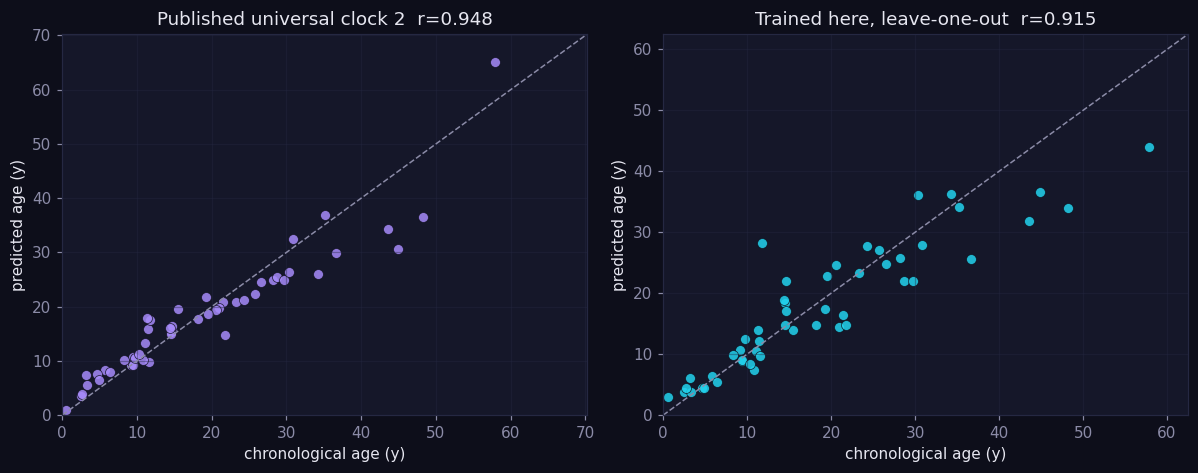

In [4]:
pub = pd.read_csv(PROC/"clock_predictions_published.csv")
scr = pd.read_csv(PROC/"clock_predictions_scratch.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (x, y, t, c) in zip(axes, [
        (pub.Age, pub.DNAmAge_clock2, "Published universal clock 2", VIOLET),
        (scr.Age, scr.PredAge_scratch, "Trained here, leave-one-out", CYAN)]):
    lim = [0, max(x.max(), y.max())*1.08]
    ax.plot(lim, lim, "--", color="#8b8ba7", lw=1)
    ax.scatter(x, y, s=42, c=c, alpha=.85, edgecolors="#0d0e1a", lw=.5)
    ax.set(xlim=lim, ylim=lim, xlabel="chronological age (y)",
           ylabel="predicted age (y)", title=f"{t}  r={np.corrcoef(x,y)[0,1]:.3f}")
plt.tight_layout()

## 3. The measure that breaks everything

The consortium's cross-species ageing rate is called **AROCM**, the average rate
of change of methylation. Reading their R code (`0_fns_v2.R::calslope2`), it is
computed like this: take the mean methylation across the CpGs in one chromatin
state, standardise it across the samples of that species, then regress it on age.

Standardising is the problem. If methylation really follows
`meth = a + b*age + noise`, then after standardising, the fitted slope is

```
AROCM = b / sqrt(b^2 * Var(age) + sigma^2)
```

When the age signal is strong relative to noise, that collapses to
`AROCM ~ 1/SD(age)`. The measure is bounded above by the inverse of the age
spread in the sample. Species sampled across a wider span in years get a smaller
rate, no biology required. And long-lived species are, necessarily, sampled
across wider spans.

So before fitting anything, check how close the observed rates sit to that
ceiling.

In [5]:
w = pd.read_csv(PROC/"species_state_arocm_wide.csv")
w["span_y"] = (w.age_range_hi - w.age_range_lo) * w.max_lifespan_y
w = w[w.span_y > 0]
a = w["BivProm2+"].abs()

for name, x in [("log max lifespan", np.log(w.max_lifespan_y)),
                ("log sampled age span", np.log(w.span_y)),
                ("log adult mass", np.log(w.adult_mass_g))]:
    print(f"corr(log AROCM, {name:24s}) = {np.corrcoef(np.log(a), x)[0,1]:+.3f}")

ceiling = 1/(w.span_y/np.sqrt(12))
print(f"\nAROCM as a fraction of its 1/SD(age) ceiling: "
      f"median {(a/ceiling).median():.2f}")

corr(log AROCM, log max lifespan        ) = -0.835
corr(log AROCM, log sampled age span    ) = -0.889
corr(log AROCM, log adult mass          ) = -0.547

AROCM as a fraction of its 1/SD(age) ceiling: median 0.58


The rate correlates more strongly with the sampled age span than with lifespan,
and sits at roughly 60% of the mechanical ceiling. This is the signature of a
measure dominated by study design.

## 4. Four models

Each adds one control.

- **M1** regresses log rate on log body mass. This is the naive analysis.
- **M2** adds log sampled age span, removing the artifact.
- **M3** adds a random intercept per taxonomic order, because mammal orders are
  not independent draws. Species within an order share ancestry, so treating
  126 species as 126 independent observations overstates the evidence.
- **M5** uses the implied correlation, `AROCM * SD(age)`, which is
  artifact-free by construction.

In [6]:
d = pd.read_csv(PROC/"species_residuals.csv")
m1 = smf.ols("log_arocm ~ log_mass", data=d).fit()
m2 = smf.ols("log_arocm ~ log_mass + log_span", data=d).fit()

print(f"M1  mass coefficient {m1.params['log_mass']:+.3f} "
      f"(SE {m1.bse['log_mass']:.3f})  p={m1.pvalues['log_mass']:.2e}  "
      f"R2={m1.rsquared:.3f}")
print(f"M2  mass coefficient {m2.params['log_mass']:+.3f} "
      f"(SE {m2.bse['log_mass']:.3f})  p={m2.pvalues['log_mass']:.3f}")
print(f"M2  span coefficient {m2.params['log_span']:+.3f} "
      f"(SE {m2.bse['log_span']:.3f})")

t = (m2.params["log_span"] + 1.0)/m2.bse["log_span"]
p = 2*stats.t.sf(abs(t), df=int(m2.df_resid))
print(f"\ntest of span coefficient against -1 (the pure-artifact prediction): "
      f"t={t:+.2f}, p={p:.3f}")
print("-> cannot reject; the span term behaves exactly as the artifact predicts")
print(f"\nmass coefficient shrinks "
      f"{(1-abs(m2.params['log_mass']/m1.params['log_mass']))*100:.0f}%")

M1  mass coefficient -0.150 (SE 0.020)  p=1.48e-11  R2=0.308
M2  mass coefficient -0.017 (SE 0.010)  p=0.099
M2  span coefficient -0.960 (SE 0.039)

test of span coefficient against -1 (the pure-artifact prediction): t=+1.02, p=0.311
-> cannot reject; the span term behaves exactly as the artifact predicts

mass coefficient shrinks 89%


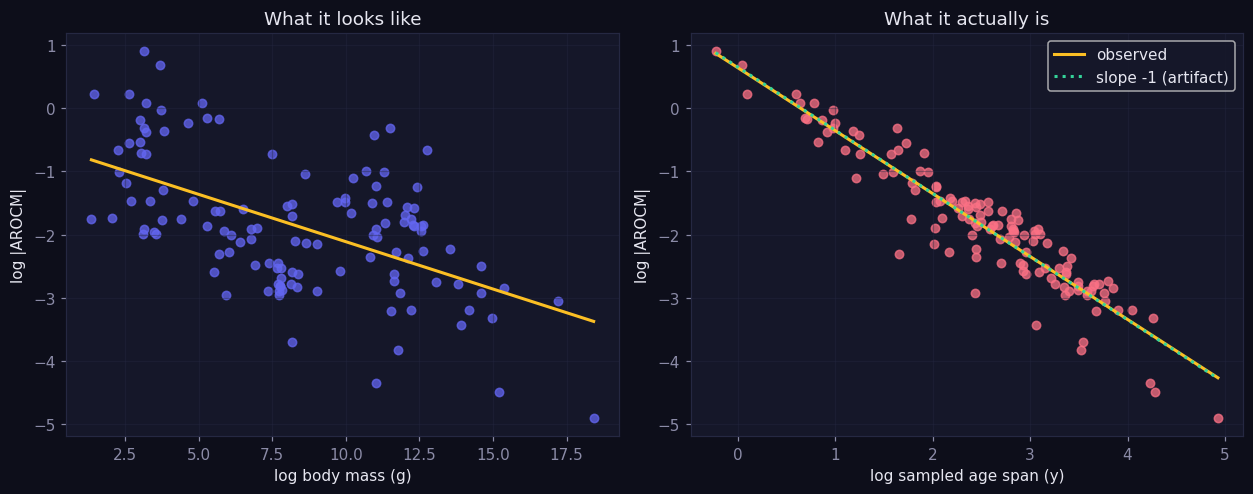

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].scatter(d.log_mass, d.log_arocm, s=30, c=INDIGO, alpha=.75)
xs = np.linspace(d.log_mass.min(), d.log_mass.max(), 50)
axes[0].plot(xs, np.polyval(np.polyfit(d.log_mass, d.log_arocm, 1), xs),
             color=AMBER, lw=2)
axes[0].set(xlabel="log body mass (g)", ylabel="log |AROCM|",
            title="What it looks like")

axes[1].scatter(d.log_span, d.log_arocm, s=30, c=ROSE, alpha=.75)
xs = np.linspace(d.log_span.min(), d.log_span.max(), 50)
axes[1].plot(xs, np.polyval(np.polyfit(d.log_span, d.log_arocm, 1), xs),
             color=AMBER, lw=2, label="observed")
c = np.mean(d.log_arocm + d.log_span)
axes[1].plot(xs, c - xs, ":", color=EMERALD, lw=2, label="slope -1 (artifact)")
axes[1].legend()
axes[1].set(xlabel="log sampled age span (y)", ylabel="log |AROCM|",
            title="What it actually is")
plt.tight_layout()

## 5. So who is actually an outlier?

Ranking residuals is not enough. Something always sits at the top of a ranking.
The test is whether a species deviates more than the scatter of all the others
justifies, corrected for the fact that we are running 126 tests at once.

Externally studentized residuals plus Benjamini-Hochberg does that. A
**studentized residual** rescales each residual by an error estimate computed
with that species held out, so an extreme point cannot inflate the yardstick
used to judge it.

In [8]:
print(f"significant outliers at q<0.05: {int(d.signif.sum())} of {len(d)}\n")
print(d[d.signif][["SpeciesCommonName","Order","resid_student","q_outlier"]]
      .to_string(index=False))

print("\nthe famous ones, before and after:")
for latin in ["Heterocephalus glaber","Balaena mysticetus","Homo sapiens","Mus musculus"]:
    r = d[d.SpeciesLatinName == latin]
    if len(r):
        r = r.iloc[0]
        print(f"  {r.SpeciesCommonName:18s} naive {r.resid_M1:+.3f} -> "
              f"corrected {r.resid_M3:+.3f}   q={r.q_outlier:.3f}")

significant outliers at q<0.05: 1 of 126

         SpeciesCommonName    Order  resid_student  q_outlier
Northern giant mouse lemur Primates       -3.80826   0.027779

the famous ones, before and after:
  Naked mole rat     naive -0.852 -> corrected +0.237   q=0.976
  Bowhead whale      naive -1.526 -> corrected -0.573   q=0.976
  Human              naive -2.082 -> corrected -0.679   q=0.497
  Mouse              naive +0.878 -> corrected -0.052   q=0.995


The naked mole rat is the clearest casualty. Naively it looks like a slow ager,
which is the story everyone expects. After the sampling correction it sits
slightly on the fast side of average and is nowhere near significance. Its
apparent slowness came from being sampled across a wide age range relative to
its size, not from unusual epigenetic stability.

The bowhead whale moves too, but less. It stays on the slow side.

## 6. Sanity checks

Before trusting a negative result, confirm the dataset reproduces things we
already know. Two independent checks: Kleiber's law, which says metabolic rate
scales as body mass to the power 0.75, and the longevity quotient, which is
observed lifespan divided by the lifespan predicted from body mass.

In [9]:
am = json.loads((RES/"aging_rate_models.json").read_text())
lq = am["lifespan_mass_allometry"]
print(f"lifespan ~ mass^{lq['exponent']:.3f} (SE {lq['se']:.3f}), R2={lq['r2']:.2f}")
if am.get("rate_of_living"):
    rol = am["rate_of_living"]
    print(f"Kleiber check: BMR ~ mass^{rol['kleiber_exponent']:.3f} "
          f"(law predicts 0.75), n={rol['n']}")
    print(f"mass-specific metabolic rate vs ageing rate: "
          f"beta={rol['beta_massspecific_bmr']:+.3f}, p={rol['p']:.3f}")

print("\nhighest longevity quotient:")
print(d.nlargest(6,"longevity_quotient")[["SpeciesCommonName","longevity_quotient"]]
      .to_string(index=False))

lifespan ~ mass^0.131 (SE 0.012), R2=0.48
Kleiber check: BMR ~ mass^0.742 (law predicts 0.75), n=55
mass-specific metabolic rate vs ageing rate: beta=+0.027, p=0.588

highest longevity quotient:
      SpeciesCommonName  longevity_quotient
                  Human            3.650556
       Little brown bat            3.173527
Greater mouse-eared bat            3.019064
         Naked mole rat            2.931803
  Greater horseshoe bat            2.554942
          Bowhead whale            2.394321


Kleiber's exponent comes back at 0.742 against a textbook 0.75, and the
longevity quotient ranking puts bats and the naked mole rat at the top, exactly
where comparative biology puts them. The data is sound. The problem is the rate
measure, not the dataset.

The rate-of-living hypothesis, which holds that animals burning energy faster
should age faster, gets no support here once sampling is controlled.

## 7. Interpretable machine learning, and an honest failure

Dividing each chromatin state's rate by the species' own genome-wide mean
cancels the `1/SD(age)` term exactly, because it is common to every state in
that animal. What survives is the *shape* of the ageing signature.

The test that matters is whether that shape predicts lifespan in a lineage the
model has never seen. Leaving out whole taxonomic orders is the strict version:
train on primates, rodents and bats, then predict carnivores.

In [10]:
it = json.loads((RES/"interpretability.json").read_text())
print(f"states correlated with lifespan at q<0.05: "
      f"{it['n_states_lifespan_significant']} of {it['n_states']}\n")
for k in ["elastic_net","random_forest"]:
    v = it["ml"][k]
    print(f"{k:14s} leave-one-order-out r={v['r']:+.3f}  R2={v['r2_oos']:+.3f}")
p = it["ml"]["permutation"]
print(f"\npermutation null mean r={p['null_mean_r']:+.3f}, "
      f"95th percentile {p['null_p95']:+.3f}, empirical p={p['empirical_p']:.3f}")

states correlated with lifespan at q<0.05: 6 of 54

elastic_net    leave-one-order-out r=-0.070  R2=-0.407
random_forest  leave-one-order-out r=-0.115  R2=-0.264

permutation null mean r=-0.039, 95th percentile +0.168, empirical p=0.627


Six states correlate with lifespan. None of it generalises. Out-of-sample
correlation is indistinguishable from zero, and the permutation test confirms
it. The within-sample associations are phylogenetic structure: closely related
species resemble each other in both chromatin dynamics and lifespan, and a model
fitted across orders picks that up without learning anything portable.

This is the result that would have been easy to miss. Reporting the six
significant states and stopping would have produced a much more exciting and
much less true story.

## 8. What does hold up

The clock CpG sites themselves.

In [11]:
ann = pd.read_csv(PROC/"clock_cpg_annotation.csv")
enr = pd.read_csv(PROC/"clock_cpg_enrichment.csv")
print(enr[["category","clock_pct","bg_pct","odds_ratio","q"]]
      .sort_values("odds_ratio", ascending=False).to_string(index=False))
print("\ngenes carrying the most clock CpGs:")
print(ann.SYMBOL.value_counts().head(15).to_string())

             category  clock_pct    bg_pct  odds_ratio        q
              fiveUTR   9.439754  7.027041    1.379137 0.003351
                 Exon  32.770530 28.641732    1.214420 0.003351
             Promoter   7.981581  6.749896    1.198302 0.115839
             threeUTR   9.746738 10.148156    0.956173 0.674497
               Intron  31.082118 32.094385    0.954235 0.525848
  Intergenic_upstream   4.374520  5.630957    0.766662 0.099715
Intergenic_downstream   4.604758  6.941567    0.647110 0.003351

genes carrying the most clock CpGs:
SYMBOL
PAX2         9
HOXB7        9
LOC440982    8
NPAS3        8
CASZ1        8
ZFHX3        7
NR2F1-AS1    7
BCOR         7
EVX2         6
FIGN         6
ZNF521       6
TBCA         6
SOCS3        5
BTRC         5
MECOM        5


PAX2, HOXB7, EVX2, NPAS3, CASZ1, ZFHX3, BCOR, ZNF521. Developmental
transcription factors and polycomb targets, the same family of genes every
methylation clock ever built has converged on. **Polycomb** is a protein complex
that keeps developmental genes switched off in adult tissue, and the sites it
guards drift steadily with age across mammals.

That is the real, portable finding. The clocks read a conserved developmental
programme. What they do not straightforwardly give us is a cross-species ageing
speedometer.

## 9. Summary

| Claim | Verdict |
|---|---|
| Methylation clocks predict age across mammals | Holds. r = 0.95 published, 0.92 retrained |
| Independent fits find the same CpGs | Holds. 7 of 31 overlap, 1.1 expected |
| Clock CpGs sit in developmental regulators | Holds. Enriched in 5' UTRs and exons |
| Epigenetic ageing rate scales with body size | Fails. 89% of it is a sampling artifact |
| Naked mole rats age unusually slowly by this measure | Fails. Reverses sign once corrected |
| Bowhead whales age slowly | Weakly holds. Survives, not significant |
| Chromatin-state signature predicts lifespan | Fails. No generalisation across orders |
| Rate of living predicts epigenetic ageing | Fails. No association |

The honest headline is that the clock is real and the speedometer is not. Fixing
that needs rate estimates computed on a common relative-age grid with the age
range held constant, which the raw arrays on GEO would support but the published
summary tables do not.